① 결측치 처리  
② Target(Recommended) 0/1 변환  
③ 수치형 변수 상관관계 확인  
④ Train / Test Split  
⑤ 인코딩 & 벡터화  
⑥ 모델 학습  

### 항공사 리뷰 텍스트 기반 추천/비추천 예측 모델
- 데이터
    - https://www.kaggle.com/datasets/naimaasif/airline-reviews
- target
    - Recommended: Yes / No


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix


# 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df1 = pd.read_csv('./data/Airline_review.csv')
df1.head()

,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended
0,0,AB Aviation,9,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,NaN,Solo Leisure,Economy Class,Moroni to Moheli,November 2019,4.0,5.0,4.0,4.0,NaN,NaN,3.0,yes
1,1,AB Aviation,1,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,Moroni to Anjouan,June 2019,2.0,2.0,1.0,1.0,NaN,NaN,2.0,no
2,2,AB Aviation,1,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,June 2019,2.0,1.0,1.0,1.0,NaN,NaN,2.0,no
3,3,Adria Airways,1,"""I will never fly again with Adria""",28th September 2019,False,Please do a favor yourself and do not fly wi...,NaN,Solo Leisure,Economy Class,Frankfurt to Pristina,September 2019,1.0,1.0,NaN,1.0,NaN,NaN,1.0,no
4,4,Adria Airways,1,"""it ruined our last days of holidays""",24th September 2019,True,Do not book a flight with this airline! My fr...,NaN,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,September 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no


| 한글 컬럼명     | 영문 컬럼명        | 설명(내용)                                    |
| ---------- | ---------------------- | ----------------------------------------- |
| 리뷰 내용      | Review                 | 고객이 작성한 항공사 이용 후기 텍스트                     |
| 추천 여부      | Recommended            | 해당 항공사를 추천하는지 여부 (Yes / No)               |


In [3]:
df1.columns

Index(['Unnamed: 0', 'Airline Name', 'Overall_Rating', 'Review_Title',
       'Review Date', 'Verified', 'Review', 'Aircraft', 'Type Of Traveller',
       'Seat Type', 'Route', 'Date Flown', 'Seat Comfort',
       'Cabin Staff Service', 'Food & Beverages', 'Ground Service',
       'Inflight Entertainment', 'Wifi & Connectivity', 'Value For Money',
       'Recommended'],
      dtype='object')

In [4]:
# Review / Recommended 남기고 모두 삭제하기 
df = df1.drop(columns=[
    'Unnamed: 0', 'Airline Name', 'Overall_Rating', 'Review_Title',
    'Review Date', 'Verified', 'Aircraft', 'Type Of Traveller',
    'Seat Type', 'Route', 'Date Flown', 'Seat Comfort',
    'Cabin Staff Service', 'Food & Beverages', 'Ground Service',
    'Inflight Entertainment', 'Wifi & Connectivity', 'Value For Money'
])
df

,Review,Recommended
0,Moroni to Moheli. Turned out to be a pretty ...,yes
1,Moroni to Anjouan. It is a very small airline...,no
2,Anjouan to Dzaoudzi. A very small airline an...,no
3,Please do a favor yourself and do not fly wi...,no
4,Do not book a flight with this airline! My fr...,no
...,...,...
23166,Bangkok to Tokyo. I’ve flown many low cost ai...,no
23167,Avoid at all costs. I booked flights to go f...,no
23168,Flight was leaving at 23.15 and after an hou...,no
23169,Zipair is JAL’s budget airline. They don’t ha...,yes


In [5]:
# # Recommended 0/1로 인코딩
# df['Recommended'] = df['Recommended'].replace({'yes': 1, 'no': 0, 'Yes': 1, 'No': 0})
# df

In [6]:
# 리뷰 텍스트 길이
# df['review_length'] = df['Review'].str.len()

# # 리뷰 단어수
# df['word_count'] = df['Review'].str.split().str.len()

# fig, axes = plt.subplots(1,2, figsize=(8,5))
# df.boxplot(column='review_length', by='Recommended', ax=axes[0])
# axes[0].set_title('리뷰 텍스트 길이')
# axes[0].set_xlabel('추천 여부')
# axes[0].set_ylabel('텍스트 길이')

# df.boxplot(column='word_count', by='Recommended', ax=axes[1])
# axes[1].set_title('리뷰 내 단어 수')
# axes[1].set_xlabel('추천 여부')
# axes[1].set_ylabel('단어 수')

# plt.suptitle('')
# plt.tight_layout()
# plt.show()

In [7]:
import re
from collections import Counter

#### 영어 단어만 추출하기

In [ ]:
# 영어 추출 및 조사 제거
for r in df['Recommended'].unique():        # Recommended 클래스별로 리뷰 텍스트를 분리

    review_text = " ".join(                                         # 공백을 사이에 두고 하나로 이어붙임
        df[df['Recommended'] == r]['Review']                        # Recommended 값이 r인 행들을 골라 Review 내용 컬럼을 가져옴
        .astype(str)                                                # 문자열로 변환
        .tolist()                                                   # list 형태로 변환
    ).lower()                                                       # 소문자로 변경

    # 영어 "단어"만 추출
    words = re.findall(r'[a-zA-Z]+', review_text)
    word_cnt = Counter(words)

    stopwords = {                                                   # 의미없는 단어 모음
        'a', 'an', 'the',
        'i', 'me', 'my', 'we', 'our', 'you', 'your',
        'they', 'their', 'them', 'he', 'she', 'it', 'its',
        'and', 'or', 'but', 'if', 'so', 'very', 'as', 'at',
        'to', 'of', 'for', 'with', 'by', 'from', 'on', 'in',
        'is', 'are', 'was', 'were', 'be', 'been', 'being',
        'have', 'has', 'had', 'do', 'did', 'does',
        'this', 'that', 'these', 'those',
        'would', 'could', 'should', 'one', 'all', 'only'
    }

    for sw in stopwords:
        word_cnt.pop(sw, None)                                      # 해당 단어가 있으면 딕셔너리에서 삭제, 없으면 None을 반환하며 다음 코드로 넘어감

    print(f'\nRecommended = {r}')
    for word, count in word_cnt.most_common(50):
        print(f'{word} : {count}회')


Recommended = yes
flight : 12412회
good : 4762회
time : 4698회
not : 4678회
service : 4400회
crew : 3791회
no : 3198회
food : 3081회
cabin : 3036회
staff : 2996회
check : 2795회
seats : 2747회
airline : 2689회
t : 2686회
seat : 2592회
flights : 2575회
which : 2456회
there : 2374회
friendly : 2291회
plane : 2042회
airlines : 2015회
air : 1931회
comfortable : 1922회
s : 1915회
aircraft : 1911회
airport : 1848회
boarding : 1836회
experience : 1833회
great : 1785회
than : 1775회
class : 1768회
again : 1632회
nice : 1617회
us : 1568회
more : 1557회
about : 1493회
both : 1486회
well : 1461회
business : 1457회
new : 1457회
when : 1436회
return : 1417회
fly : 1397회
out : 1392회
first : 1381회
excellent : 1377회
clean : 1348회
meal : 1331회
also : 1305회
passengers : 1300회

Recommended = no
flight : 30752회
not : 20311회
no : 14740회
t : 12207회
airline : 10166회
service : 8433회
us : 8003회
time : 7941회
when : 7638회
there : 7526회
hours : 7018회
airport : 6659회
get : 6331회
after : 6001회
will : 5873회
check : 5563회
staff : 5441회
told : 5412회
which : 

#### 데이터 분리

In [9]:
# 데이터 분리
X = df['Review']
y = df['Recommended']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

print(f'X_train : {len(X_train)}개, X_test : {len(X_test)}개, y_train : {len(y_train)}개, y_test : {len(y_test)}개')


X_train : 18536개, X_test : 4635개, y_train : 18536개, y_test : 4635개


#### 벡터화

In [10]:
# 벡터화 
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,  # 최대 feature 수 : 추출할 최대 단어 수
    min_df=2,           # 최소 문서 빈도 : 최소 2개 문서에는 등장해야 feature로 사용
    max_df=0.8,         # 최대 문서 빈도 : 전체 문서 중 80% 이하에서 등장하는 단어만 사용
    ngram_range=(1,3),  # 1~3단어 조합까지 벡터화 (unigram, trigram)
    sublinear_tf=True,  # tf 값에 log 적용 : 빈도수에 log 스케일 적용
    use_idf=True        # IDF 사용
)

# 학습 데이터로 벡터라이저 학습 및 변환(문자->벡터)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# 테스트 데이터로 벡터라이저 학습데이터와 동일한 기준으로 변환(문자->벡터)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f'train : {X_train_tfidf.shape}')
print(f'test : {X_test_tfidf.shape}')

train : (18536, 1000)
test : (4635, 1000)


#### Recommended 라벨 인코딩

In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
label = LabelEncoder()

y_train_enc = label.fit_transform(y_train)
y_test_enc = label.transform(y_test)

print(label.classes_)
print(y_test_enc)

['no' 'yes']
[0 0 0 ... 1 0 0]


#### 다층 퍼셉트론

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader 
import optuna 

c:\Users\user\dl\dl_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tensor 형태로 변환 
- X_train_tfidf.shape : (18536, 1000)
- X_test_tfidf.shape : (4635, 1000)
- y_train_enc.shape : (18536,)
- y_test_enc.shape : (4635,)

1차원인 y => x와 동일한 2차원으로 변경

In [14]:
# tensor 형태로 변환
X_train_t = torch.FloatTensor(X_train_tfidf.toarray())
X_test_t = torch.FloatTensor(X_test_tfidf.toarray())

y_train_t = torch.FloatTensor(y_train_enc).view(-1,1)   
y_test_t = torch.FloatTensor(y_test_enc).view(-1,1)

print(X_train_t.shape)
print(X_test_t.shape)
print(y_train_t.shape)
print(y_test_t.shape)

torch.Size([18536, 1000])
torch.Size([4635, 1000])
torch.Size([18536, 1])
torch.Size([4635, 1])


In [15]:
# 미니 배치 설정
train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(
    train_ds, 
    batch_size=64, 
    shuffle=True
)

test_loader = DataLoader(
    test_ds, 
    batch_size=64, 
    shuffle=False
)

In [16]:
# 다층 퍼셉트론
model = nn.Sequential(
    nn.Linear(X_train_t.size(-1), 128),
    nn.ReLU(),

    nn.Linear(128, 64),
    nn.ReLU(),

    nn.Linear(64, 32),
    nn.ReLU(),

    nn.Linear(32, y_train_t.size(-1)),
    nn.Sigmoid()
)


In [17]:
# 손실함수와 옵티마이저 설정
criterion = nn.BCELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [18]:
# 학습 함수
# criterion = nn.BCEWithLogitsLoss()

def train(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0

    for batch_X, batch_y in loader:
        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    return total_loss / len(loader)


In [19]:
# 평가함수
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch_X, batch_y in loader:
            output = model(batch_X)
            loss = criterion(output, batch_y)
            total_loss += loss.item()
            all_preds.extend(output.round().numpy())
            all_targets.extend(batch_y.numpy())
    
    return total_loss / len(loader), all_preds, all_targets

In [20]:
# 학습 및 검증 수행
epochs = 50
train_loss_history = []
test_loss_history = []

for epoch in range(epochs):
    avg_train_loss = train(model, train_loader, criterion, optimizer)
    avg_test_loss, preds, targets = evaluate(model, test_loader, criterion)

    train_loss_history.append(avg_train_loss)
    test_loss_history.append(avg_test_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Test Loss={avg_test_loss:.4f}')
        

Epoch 10: Train Loss=0.2243, Test Loss=0.2599
Epoch 20: Train Loss=0.2101, Test Loss=0.2701
Epoch 30: Train Loss=0.1937, Test Loss=0.2768
Epoch 40: Train Loss=0.1678, Test Loss=0.2879
Epoch 50: Train Loss=0.1298, Test Loss=0.3199


In [21]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix,classification_report

cm = confusion_matrix(targets, preds)
print(classification_report(targets, preds))

              precision    recall  f1-score   support

         0.0       0.92      0.91      0.92      3065
         1.0       0.83      0.84      0.84      1570

    accuracy                           0.89      4635
   macro avg       0.87      0.88      0.88      4635
weighted avg       0.89      0.89      0.89      4635



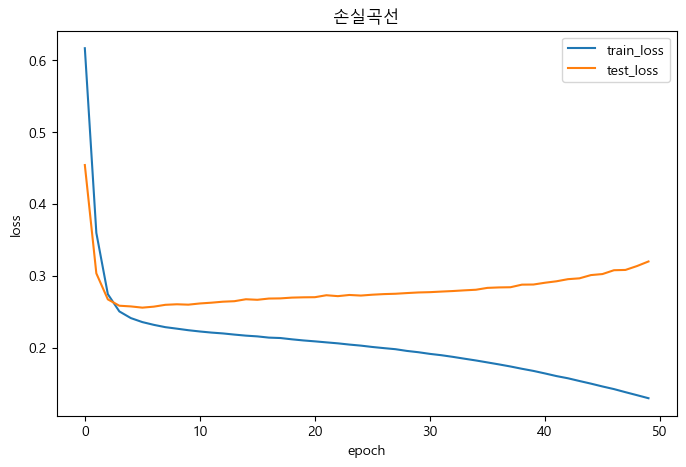

In [27]:
plt.figure(figsize=(8,5))
plt.plot(train_loss_history, label='train_loss')
plt.plot(test_loss_history, label='test_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('손실곡선')
plt.legend()
plt.show()

test_loss가 점점 올라감 -> 과적합

early stopping / dropout / Weight Decay 이용해보기

In [23]:
def predict_review(text):
    # 1. 텍스트를 숫자로 변환
    tfidf_sample = tfidf_vectorizer.transform([text]).toarray()
    tfidf_tensor = torch.FloatTensor(tfidf_sample)
    
    # 2. 모델 예측
    model.eval()
    with torch.no_grad():
        output = model(tfidf_tensor)
        prob = output.item()
        result = "추천(Yes)" if prob >= 0.5 else "비추천(No)"
        
    print(f"리뷰: {text}")
    print(f"예측 결과: {result} (확률: {prob:.2%})")

# 테스트 실행
predict_review("The flight was amazing and the crew was so friendly!")

리뷰: The flight was amazing and the crew was so friendly!
예측 결과: 추천(Yes) (확률: 97.90%)
